<a href="https://colab.research.google.com/github/putrileonita523/UTS_BIG-DATA_PUTRI-LEONITA/blob/main/UTS_BIG-DATA_PUTRI-LEONITA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-play-scraper


In [2]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.android.chrome',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [3]:
import pandas as pd

df = pd.read_csv('ulasan_google_play.csv')

df.head()

,userName,score,at,content
0,bintang feriadi,5,2026-05-05 07:23:51,TOP !! (...semoga spt yg diharapkan !!)
1,M Farel andika,1,2026-05-05 07:23:43,[5/ m m4; ] Farel: oke bang
2,Widartoto Handhy,5,2026-05-05 07:20:10,bagus
3,Abid Cbs,1,2026-05-05 06:56:29,"Aneh sama ni aplikasi adaa aja buq nya, apalag..."
4,herry bjb,5,2026-05-05 06:56:17,sangat bagus


In [4]:
pip install textblob

In [5]:
from textblob import TextBlob

def analisis_sentimen(text):
    analisis = TextBlob(str(text))

    if analisis.sentiment.polarity > 0:
        return 'Positif'
    elif analisis.sentiment.polarity < 0:
        return 'Negatif'
    else:
        return 'Netral'

df['sentimen'] = df['content'].apply(analisis_sentimen)

df.head()

,userName,score,at,content,sentimen
0,bintang feriadi,5,2026-05-05 07:23:51,TOP !! (...semoga spt yg diharapkan !!),Positif
1,M Farel andika,1,2026-05-05 07:23:43,[5/ m m4; ] Farel: oke bang,Positif
2,Widartoto Handhy,5,2026-05-05 07:20:10,bagus,Netral
3,Abid Cbs,1,2026-05-05 06:56:29,"Aneh sama ni aplikasi adaa aja buq nya, apalag...",Netral
4,herry bjb,5,2026-05-05 06:56:17,sangat bagus,Netral


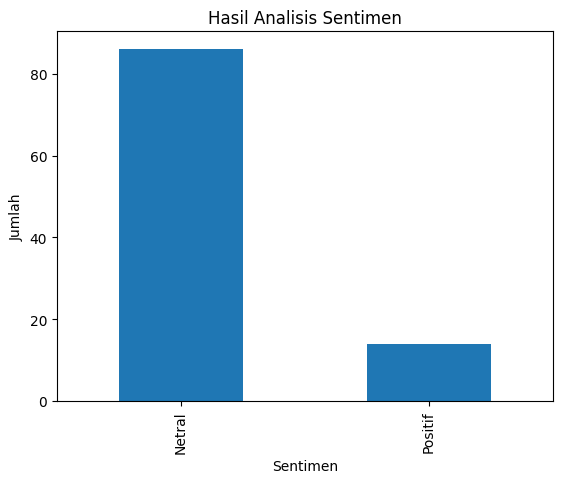

In [6]:
import matplotlib.pyplot as plt

jumlah_sentimen = df['sentimen'].value_counts()

jumlah_sentimen.plot(kind='bar')

plt.title('Hasil Analisis Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

plt.show()